In [2]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [4]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

/Users/dkonoplya05/Projects/cv/venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [6]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [7]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1308641].


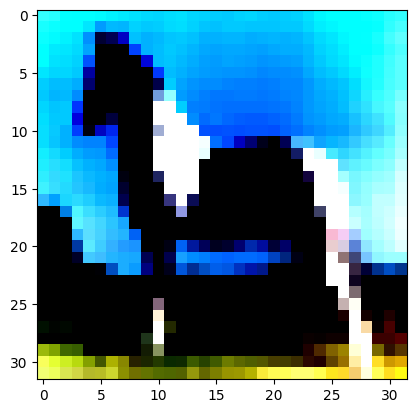

In [8]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [9]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [10]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [11]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [25]:
class Trainer:
    def __init__(self, config, model, transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = model.to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
        }

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            print(f'Epoch {epoch + 1} / {self.config['num_epochs']}', train_loss, val_loss, val_acc)

        test_loss, test_acc = self.test_step()
        self.history['test_loss'] = test_loss
        self.history['test_acc'] = test_acc
        print(f'Test loss {test_loss}, test acc {test_acc}')

        return self.history

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader, desc="Training", leave=False):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader, desc="Validation", leave=False):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader, desc="Testing", leave=False):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [28]:
trainer_cnn = Trainer(config, model=BasicCNN(), transform=transform)

/Users/dkonoplya05/Projects/cv/venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [29]:
history_cnn = trainer_cnn.run()

Epoch 1 / 10 1.5736870556212843 1.4222368937504442 49.01


Epoch 2 / 10 1.2882660379805886 1.2678671064256113 54.300000000000004


Epoch 3 / 10 1.2053694296568727 1.2298795799665814 56.830000000000005


Epoch 4 / 10 1.1726652616129134 1.21848529803602 56.599999999999994


Epoch 5 / 10 1.135766988935562 1.2779301563395729 56.35


...

Epoch 7 / 10 0.8917661313050852 1.0454082232487352 63.13999999999999


Epoch 8 / 10 0.8658480124351696 1.0497767457479164 63.28


Epoch 9 / 10 0.845621576895729 1.0461808005465736 63.42


Epoch 10 / 10 0.8290673315334625 1.046482724479482 63.36000000000001


Test loss 1.0516499273384674, test acc 63.36000000000001


# ResNet-18

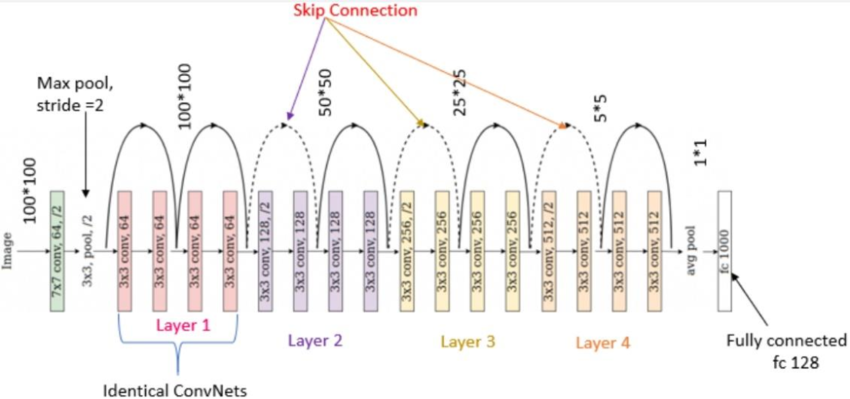

In [36]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        # Применить свертки + skip connection

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity  # skip connection
        out = F.relu(out)

        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Сделать 4 блока
        self.layer1 = self.make_layer(out_channels=64, blocks=2, stride=1)
        self.layer2 = self.make_layer(out_channels=128, blocks=2, stride=2)
        self.layer3 = self.make_layer(out_channels=256, blocks=2, stride=2)
        self.layer4 = self.make_layer(out_channels=512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(ResNetBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResNetBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [34]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN

In [37]:
trainer_resnet = Trainer(config, model=ResNet18(), transform=transform)
history_resnet = trainer_resnet.run()

/Users/dkonoplya05/Projects/cv/venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch 1 / 10 1.789140077444692 2.4734370150143588 42.26


Epoch 2 / 10 1.3372474002381103 1.2538855000387263 55.25


Epoch 3 / 10 1.088849586419785 1.048467140409011 63.53


Epoch 4 / 10 0.9209879962400126 0.9307128251353397 67.14


...

Epoch 7 / 10 0.4259740327017757 0.784089826330354 75.03


Epoch 8 / 10 0.3492788137814488 0.809480343438402 75.39


Epoch 9 / 10 0.2703718070071726 0.9039248582683032 74.9


Epoch 10 / 10 0.19273033723854027 1.0387824321094947 74.44


Test loss 1.064914661117747, test acc 74.29


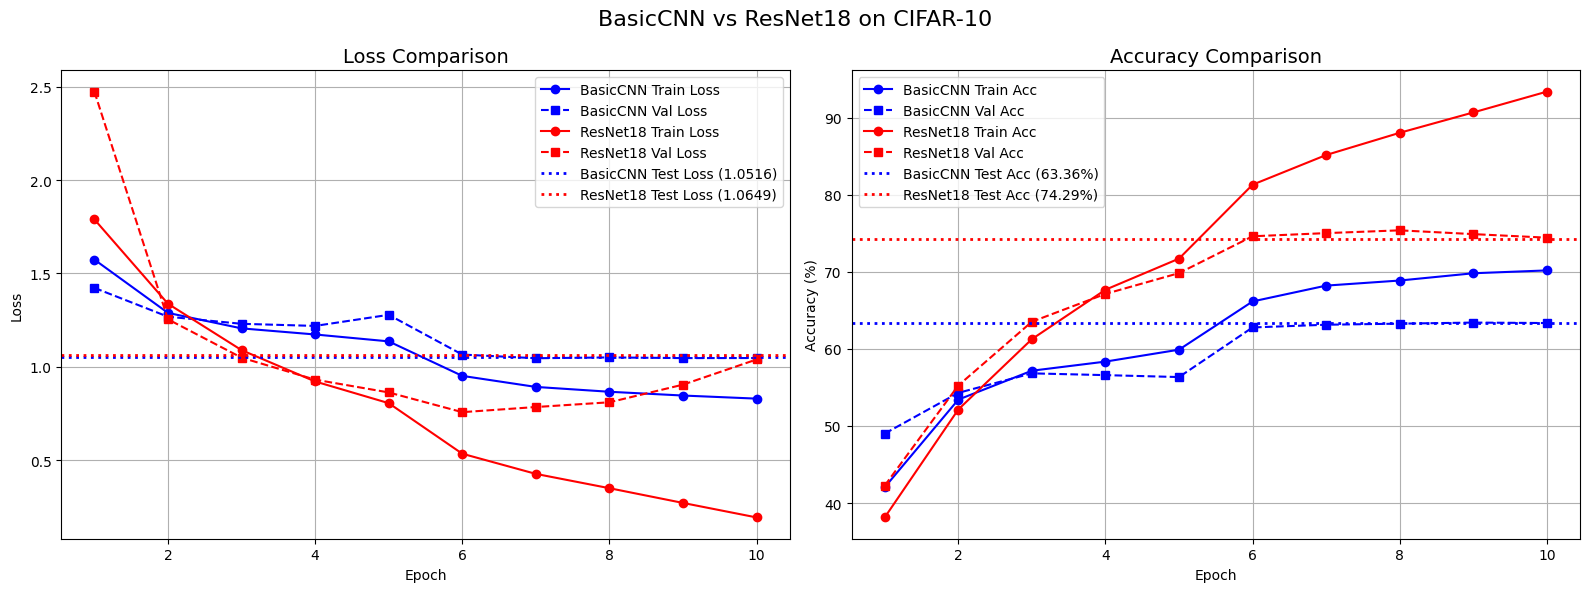

In [41]:
epochs = range(1, config['num_epochs'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Loss ---
axes[0].plot(epochs, history_cnn['train_loss'], 'b-o', label='BasicCNN Train Loss')
axes[0].plot(epochs, history_cnn['val_loss'], 'b--s', label='BasicCNN Val Loss')
axes[0].plot(epochs, history_resnet['train_loss'], 'r-o', label='ResNet18 Train Loss')
axes[0].plot(epochs, history_resnet['val_loss'], 'r--s', label='ResNet18 Val Loss')

axes[0].axhline(y=history_cnn['test_loss'], color='blue', linestyle=':', linewidth=2,
                label=f"BasicCNN Test Loss ({history_cnn['test_loss']:.4f})")
axes[0].axhline(y=history_resnet['test_loss'], color='red', linestyle=':', linewidth=2,
                label=f"ResNet18 Test Loss ({history_resnet['test_loss']:.4f})")

axes[0].set_title('Loss Comparison', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy ---
axes[1].plot(epochs, history_cnn['train_acc'], 'b-o', label='BasicCNN Train Acc')
axes[1].plot(epochs, history_cnn['val_acc'], 'b--s', label='BasicCNN Val Acc')
axes[1].plot(epochs, history_resnet['train_acc'], 'r-o', label='ResNet18 Train Acc')
axes[1].plot(epochs, history_resnet['val_acc'], 'r--s', label='ResNet18 Val Acc')

axes[1].axhline(y=history_cnn['test_acc'], color='blue', linestyle=':', linewidth=2,
                label=f"BasicCNN Test Acc ({history_cnn['test_acc']:.2f}%)")
axes[1].axhline(y=history_resnet['test_acc'], color='red', linestyle=':', linewidth=2,
                label=f"ResNet18 Test Acc ({history_resnet['test_acc']:.2f}%)")

axes[1].set_title('Accuracy Comparison', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('BasicCNN vs ResNet18 on CIFAR-10', fontsize=16)
plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()